# 10. Ancash

[Notebook 9](09_arequipa_dem.ipynb) ran the whole machine over Arequipa. This one runs
**the same three searches over different ground** — the Cordillera Blanca and the
Callejón de Huaylas, 300 km of the steepest tropical mountains on Earth, with Huascarán
at 6,768 m in the middle of them.

The point is not that Ancash is new terrain. It is that **every transferable criterion
is held fixed**, so a difference in the answer is a difference in the ground rather than
a difference in the question. That is a claim this notebook checks rather than asserts,
in the second cell below.

In [1]:
import json
import os

import numpy as np

from oroscope import explain
from oroscope import site_searcher as ss

## What is the same, and what is not

Both configurations were derived from Arequipa's by changing the DEM path and the label,
and nothing else. Rather than ask you to believe that, here is the diff.

In [2]:
def settings(path):
    """A configuration without its commentary: `_comment*` keys are prose."""
    with open(path) as f:
        return {k: v for k, v in json.load(f).items() if not k.startswith("_")}


for experiment in ("grand", "tambo"):
    a = settings(os.path.join("..", "config", f"{experiment}_arequipa_full.json"))
    n = settings(os.path.join("..", "config", f"{experiment}_ancash_full.json"))
    keys = sorted(set(a) | set(n))
    differ = [k for k in keys if a.get(k) != n.get(k)]
    print(f"{experiment.upper()}: {len(keys)} settings, {len(differ)} differ")
    for k in differ:
        print(f"    {k:<14} arequipa={a.get(k)!r}")
        print(f"    {'':<14} ancash  ={n.get(k)!r}")

GRAND: 52 settings, 3 differ
    dem_path       arequipa='../input/dem/arequipa_SRTMGL1.tif'
                   ancash  ='../input/dem/ancash_SRTMGL1.tif'
    region_name    arequipa='Arequipa, full DEM (GRAND)'
                   ancash  ='Ancash, full DEM (GRAND)'
    rfi_zones      arequipa='arequipa'
                   ancash  ='none'
TAMBO: 60 settings, 2 differ
    dem_path       arequipa='../input/dem/arequipa_SRTMGL1.tif'
                   ancash  ='../input/dem/ancash_SRTMGL1.tif'
    region_name    arequipa='Arequipa, full DEM (TAMBO)'
                   ancash  ='Ancash, full DEM (TAMBO)'


**TAMBO is an exact repeat**: the two differences are the file it reads and the name it
prints.

**GRAND differs in one real setting, `rfi_zones`.** Arequipa's run excludes five
hand-curated circles — Arequipa city, Majes, Cerro Verde, La Joya, Mollendo — and there
is no Ancash preset. Inventing a five-circle Ancash list would have injected a new
assumption into a run whose entire purpose is comparison, so this run excludes nothing
and says so. The size of it: Arequipa's zones cover about 3,500 km² of a ~120,000 km²
box, so **read Ancash's GRAND area as at most ~3% flattered** on that account.

The real settlements are not ignored — 774 of them, from OpenStreetMap, are on the maps
below. They are context here, not a filter.

## Read, not run

The cells below open results produced locally and stored in `results/ancash_full/`. To
produce or refresh them:

```bash
export OPENTOPOGRAPHY_API_KEY=...          # free, see the CLI page
cd src && oroscope-fetch-dem --region ancash
python -m oroscope.fetch_roads --dem ../input/dem/ancash_SRTMGL1.tif --places

python tools/run_full_dem.py --region ancash --dry-run
python tools/run_full_dem.py --region ancash
```

Ancash is 69 Mpx against Arequipa's 129, so it costs roughly half as much: about
thirteen minutes for GRAND and under a minute for TAMBO.

In [3]:
STORE = os.path.abspath(os.path.join("..", "results", "ancash_full"))
AREQUIPA_STORE = os.path.abspath(os.path.join("..", "results", "arequipa_full"))


def load(store, label):
    path = os.path.join(store, f"{label}_results.json")
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)


runs = {label: load(STORE, label) for label in ("grand", "tambo")}
reference = {label: load(AREQUIPA_STORE, label) for label in ("grand", "tambo")}
for label, r in runs.items():
    print(f"ancash {label:<6} {'loaded' if r else 'NOT IN THE STORE YET'}")
for label, r in reference.items():
    print(f"arequipa {label:<4} {'loaded' if r else 'not present'}")

ancash grand  loaded
ancash tambo  loaded
arequipa grand loaded
arequipa tambo loaded


## The terrain, before the searches

The two DEMs can be compared without running anything, and doing so makes a prediction
worth holding the results against. Slope is computed in tiles so that a 129 Mpx DEM does
not need 1.5 GB of gradients at once.

In [4]:
def slope_profile(tif, origin_lat, bands=(("GRAND 3-25", 3.0, 25.0),
                                          ("TAMBO 20-60", 20.0, 60.0)), block=2048):
    """Median slope and band shares over a DEM, accumulated tile by tile."""
    import tifffile
    grid = ss.resolve_grid_geometry(tif, origin_lat)
    z = tifffile.imread(tif)
    rows = z.shape[0]
    hist = np.zeros(9001)                       # 0.01 degree bins, 0-90
    counts = {name: 0 for name, _, _ in bands}
    total = 0
    for r0 in range(0, rows, block):
        r1 = min(rows, r0 + block)
        lo, hi = max(0, r0 - 1), min(rows, r1 + 1)
        tile = z[lo:hi].astype(np.float32)
        dy, dx = np.gradient(tile, grid.cell_size_y, grid.cell_size_x)
        slope = np.degrees(np.arctan(np.hypot(dy, dx)))[r0 - lo:r1 - lo]
        land = z[r0:r1] > 0                     # the sea is exactly 0 and has no slope
        s = slope[land]
        if not s.size:
            continue
        total += s.size
        hist += np.histogram(s, bins=9001, range=(0.0, 90.0))[0]
        for name, a, b in bands:
            counts[name] += int(((s >= a) & (s <= b)).sum())
    median = float((np.searchsorted(np.cumsum(hist), total / 2.0) + 0.5) / 100.0)
    return {"Mpx": z.size / 1e6, "median slope": median,
            **{name: 100.0 * counts[name] / total for name, _, _ in bands}}


DEMS = {"Arequipa": ("arequipa_SRTMGL1.tif", -14.5553),
        "Ancash":   ("ancash_SRTMGL1.tif",   -8.04958)}
terrain = {}
for name, (stem, lat) in DEMS.items():
    tif = os.path.abspath(os.path.join("..", "input", "dem", stem))
    if os.path.exists(tif):
        terrain[name] = slope_profile(tif, lat)

if terrain:
    cols = list(next(iter(terrain.values())))
    print(f"{'':<10}" + "".join(f"{c:>16}" for c in cols))
    for name, row in terrain.items():
        print(f"{name:<10}" + "".join(f"{row[c]:>16.1f}" for c in cols))
else:
    print("neither DEM is here; the measured values are quoted in the text below")

                       Mpx    median slope      GRAND 3-25     TAMBO 20-60
Arequipa             128.6            11.1            70.3            24.1
Ancash                68.6            23.0            52.0            58.0


**Ancash is twice as steep.** Median slope 23.0° against Arequipa's 11.1°, and the
consequence for the two experiments runs in opposite directions:

| share of land in the band | Arequipa | Ancash |
| --- | --- | --- |
| GRAND, 3–25° deployable | 70.3% | **52.0%** |
| TAMBO, 20–60° near wall | 24.1% | **58.0%** |

So before a single ray is traced: **Ancash should be worse for GRAND per unit area and
much better for TAMBO.** GRAND wants ground gentle enough to stand an array on and
Ancash keeps giving it cliffs; TAMBO wants exactly those cliffs. Hold that against what
the searches actually found.

## What the searches found

In [5]:
def summary(results):
    if not results:
        return None
    r = results["results"]
    sites = r.get("sites") or []
    return {"sites": r.get("total_sites"),
            "area km2": sum(s.get("area_km2", 0.0) for s in sites),
            "capacity": r.get("total_capacity")}


print(f"{'':<22}{'sites':>8}{'area km2':>14}{'capacity':>12}")
for label in ("grand", "tambo"):
    for region, table in (("Arequipa", reference), ("Ancash", runs)):
        s = summary(table.get(label))
        if s:
            print(f"{label.upper() + ', ' + region:<22}{s['sites']:>8,}"
                  f"{s['area km2']:>14,.1f}{s['capacity']:>12,}")

                         sites      area km2    capacity
GRAND, Arequipa              1      88,527.5     101,948
GRAND, Ancash                1      43,091.2      49,447
TAMBO, Arequipa             85         991.6      47,136
TAMBO, Ancash               58         673.1      31,249


In [6]:
for label in ("grand", "tambo"):
    a, n = summary(reference.get(label)), summary(runs.get(label))
    if not (a and n):
        continue
    print(f"{label.upper()}  Ancash / Arequipa")
    for k in ("area km2", "capacity", "sites"):
        if a[k]:
            print(f"    {k:<10} {n[k] / a[k]:6.2f}x   "
                  f"({n[k]:,.0f} against {a[k]:,.0f})")
    print()

GRAND  Ancash / Arequipa
    area km2     0.49x   (43,091 against 88,528)
    capacity     0.49x   (49,447 against 101,948)
    sites        1.00x   (1 against 1)

TAMBO  Ancash / Arequipa
    area km2     0.68x   (673 against 992)
    capacity     0.66x   (31,249 against 47,136)
    sites        0.68x   (58 against 85)



Ancash is 0.533× Arequipa's pixel count, so that is the ratio to read everything
against: **anything near 0.53× means "the same ground, less of it", and a departure from
it is the terrain talking.**

And the terrain talks loudly. Per pixel, **GRAND is 0.91× and TAMBO is 2.93×** — the
prediction confirmed in both directions, from a comparison made before either search
ran.

GRAND's loss is milder than the naive 0.74× the band shares suggested, because its 1 km
closing element fills in around a mask that steep ground fragments. TAMBO's gain
*exceeds* its naive 2.41%, because **both** of its stages improve at once: the slope
screen keeps 33.9 million pixels in Ancash against 26.8 million in Arequipa — more
candidates from a DEM half the size — and the share of those that then accept a
direction rises from 9.7% to 15.1%. GRAND's acceptance moves the other way, 61.6% down
to 54.9%.

**So Ancash is a worse GRAND site and a much better TAMBO site than Arequipa, per unit
of ground.** That is the result, and it is a statement about mountains rather than about
software: TAMBO needs canyon walls and the Cordillera Blanca is made of them.

## Where each run lost its candidates

In [7]:
for label in ("grand", "tambo"):
    print(f"=== {label.upper()} ===")
    for region, table in (("Arequipa", reference), ("Ancash", runs)):
        results = table.get(label)
        if not results:
            continue
        funnel = results["funnel"]
        binding = explain.binding_constraint(funnel)
        stages = list(funnel.items())
        print(f"  {region:<9} binds at: {binding['stage']}  "
              f"({100 * binding['kept_fraction']:.1f}% kept there)")
        print(f"  {'':<9} knob:     {binding['knob'].split(',')[0]}")
        print(f"  {'':<9} overall:  {stages[0][1]:>13,} px -> {stages[-1][1]:>12,} "
              f"({100 * stages[-1][1] / stages[0][1]:.2f}%)")
    print()

=== GRAND ===
  Arequipa  binds at: directions accepted  (61.6% kept there)
            knob:     the arrival window (elev_min_deg/elev_max_deg)
            overall:    128,601,012 px ->   96,928,896 (75.37%)
  Ancash    binds at: slope 3.0-25.0 deg  (44.4% kept there)
            knob:     min_slope_deg / max_slope_deg
            overall:     68,571,090 px ->   45,978,976 (67.05%)

=== TAMBO ===
  Arequipa  binds at: score >= 0.35  (11.0% kept there)
            knob:     min_score -- or switch to --score_percentile
            overall:    128,601,012 px ->    1,085,648 (0.84%)
  Ancash    binds at: score >= 0.35  (10.8% kept there)
            knob:     min_score -- or switch to --score_percentile
            overall:     68,571,090 px ->      718,128 (1.05%)



**GRAND's binding constraint changed between the two regions, and TAMBO's did
not.** At Arequipa, GRAND was limited by `directions accepted` — plenty of deployable
ground, and the arrival geometry decided. At Ancash it is limited by
`slope 3.0-25.0 deg`: the mountains simply do not offer enough ground gentle enough to
stand an array on, and the search never gets as far as asking what that ground can see.

TAMBO binds at `directions accepted` in both, but from opposite sides — 9.7% of its
strided candidates accept a direction at Arequipa against 15.1% at Ancash.

This is the single most useful line in the comparison: **a criterion that binds is a
statement about the ground, not about the configuration**, and it moved when only the
ground moved.

## The maps

In [8]:
from IPython.display import Image, display


def show_figure(path, width=1100, caption=None):
    """Displays a figure the pipeline wrote, downscaled so the notebook stays small.

    The searcher saves its map to disk and says where; a notebook that only prints the
    path makes the reader go and find it. Downscaled because the full-resolution PNG is
    a megabyte or two and these outputs are committed.
    """
    if not os.path.exists(path):
        print(f"not here yet: {os.path.relpath(path)}")
        return
    try:
        from PIL import Image as PILImage
        import io as _io
        img = PILImage.open(path)
        if img.width > width:
            img = img.resize((width, round(img.height * width / img.width)),
                             PILImage.LANCZOS)
        buf = _io.BytesIO()
        img.convert("RGB").save(buf, format="PNG", optimize=True)
        data = buf.getvalue()
        # A shaded terrain map is photographic and does not compress as PNG: the full
        # Arequipa map is 1.1 MB at this width and 190 KB as JPEG, for no visible
        # difference. Line art stays PNG, where JPEG would ring around every edge.
        if len(data) > 250 * 1024:
            jpg = _io.BytesIO()
            img.convert("RGB").save(jpg, format="JPEG", quality=82, optimize=True)
            data = jpg.getvalue()
    except Exception:                       # pillow absent: show it full size
        with open(path, "rb") as f:
            data = f.read()
    if caption:
        print(caption)
    display(Image(data=data))

GRAND over Ancash


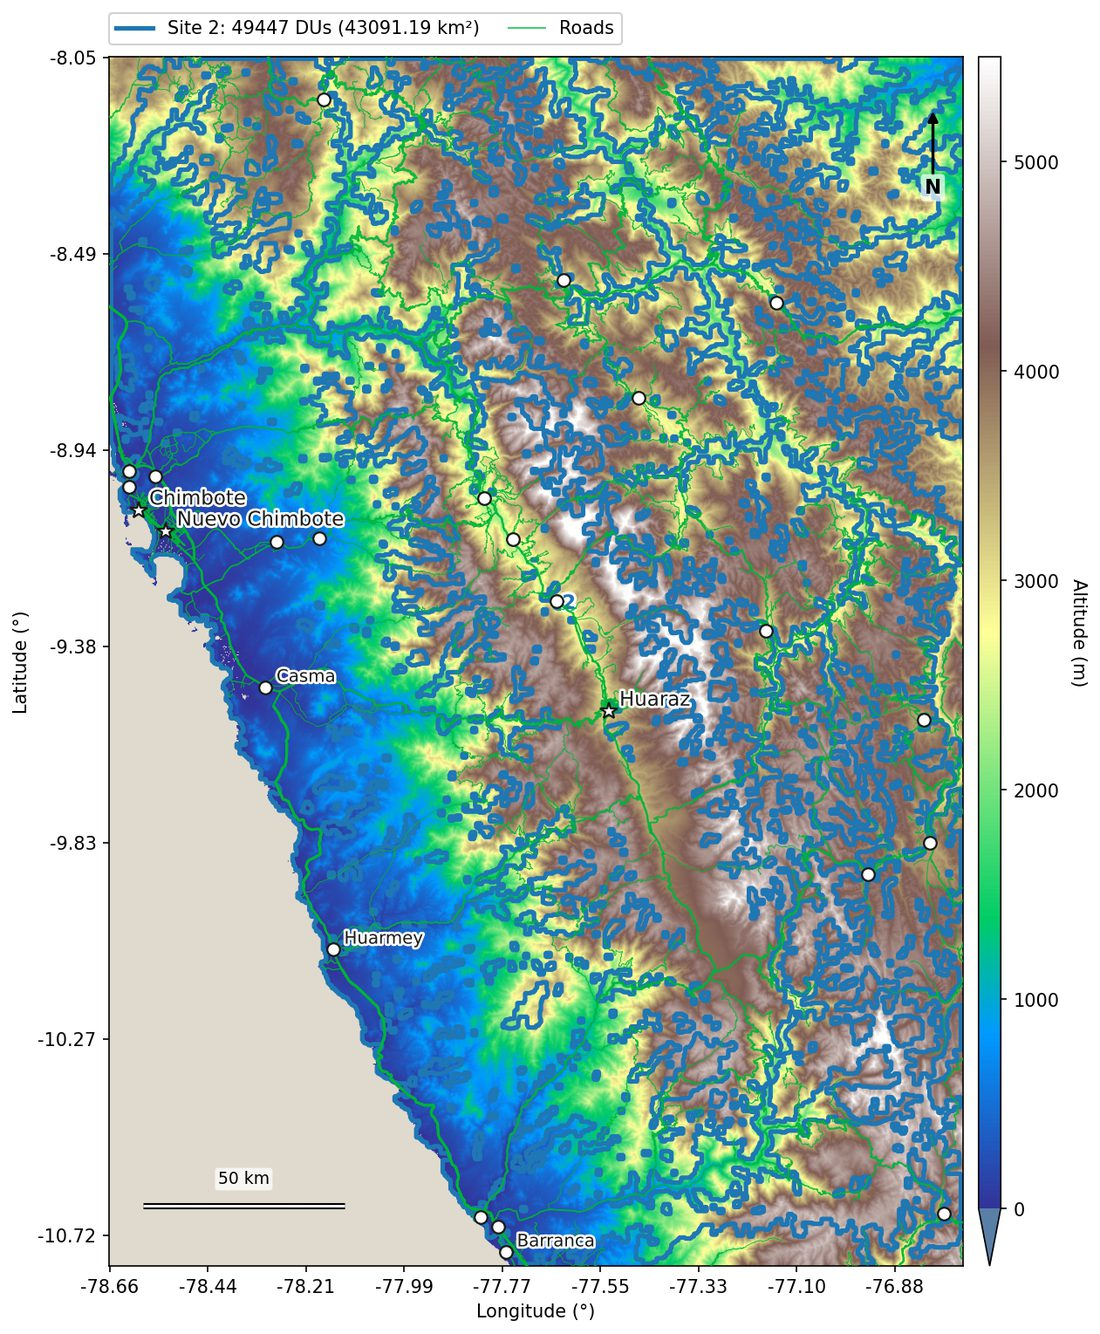

TAMBO over Ancash


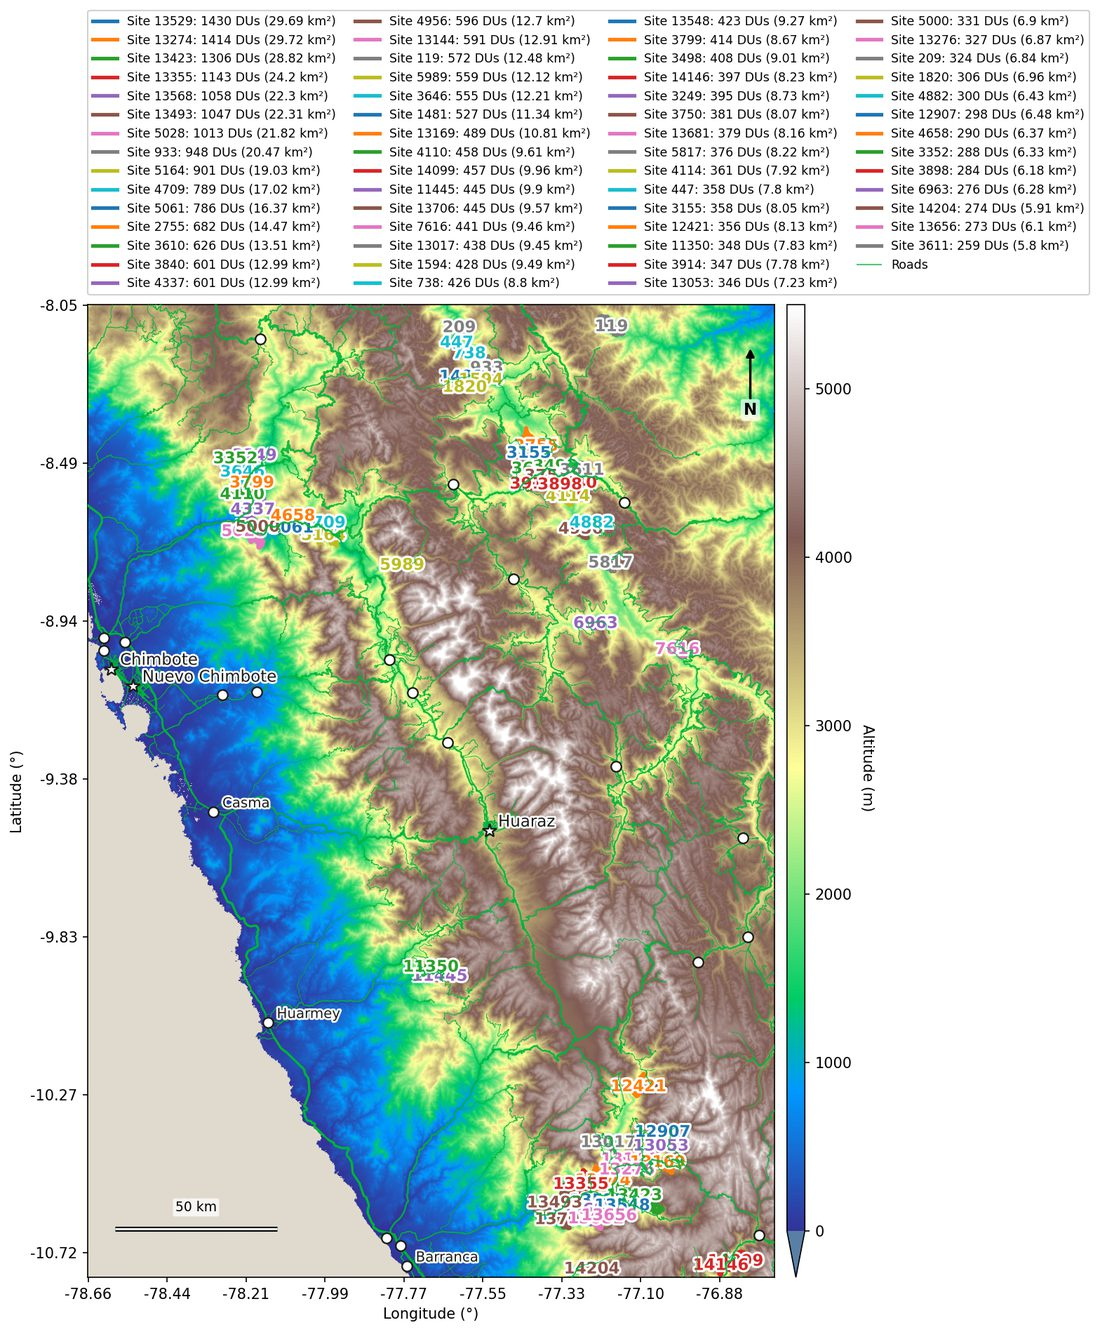

In [9]:
OUT = os.path.abspath(os.path.join("..", "output"))
for label, title in (("grand", "GRAND over Ancash"), ("tambo", "TAMBO over Ancash")):
    import glob
    found = sorted(glob.glob(os.path.join(OUT, f"ancash_full_{label}",
                                          "oroscope_results*.png")))
    show_figure(found[0] if found else os.path.join(OUT, "missing.png"),
                caption=title)

### Both at once

The combination, revealed one experiment at a time so the overlay is readable. Every
element that is not a category — terrain, colour bar, roads, towns, scale bar, legend —
is identical between the three frames, so what changes is only the result.

GRAND alone


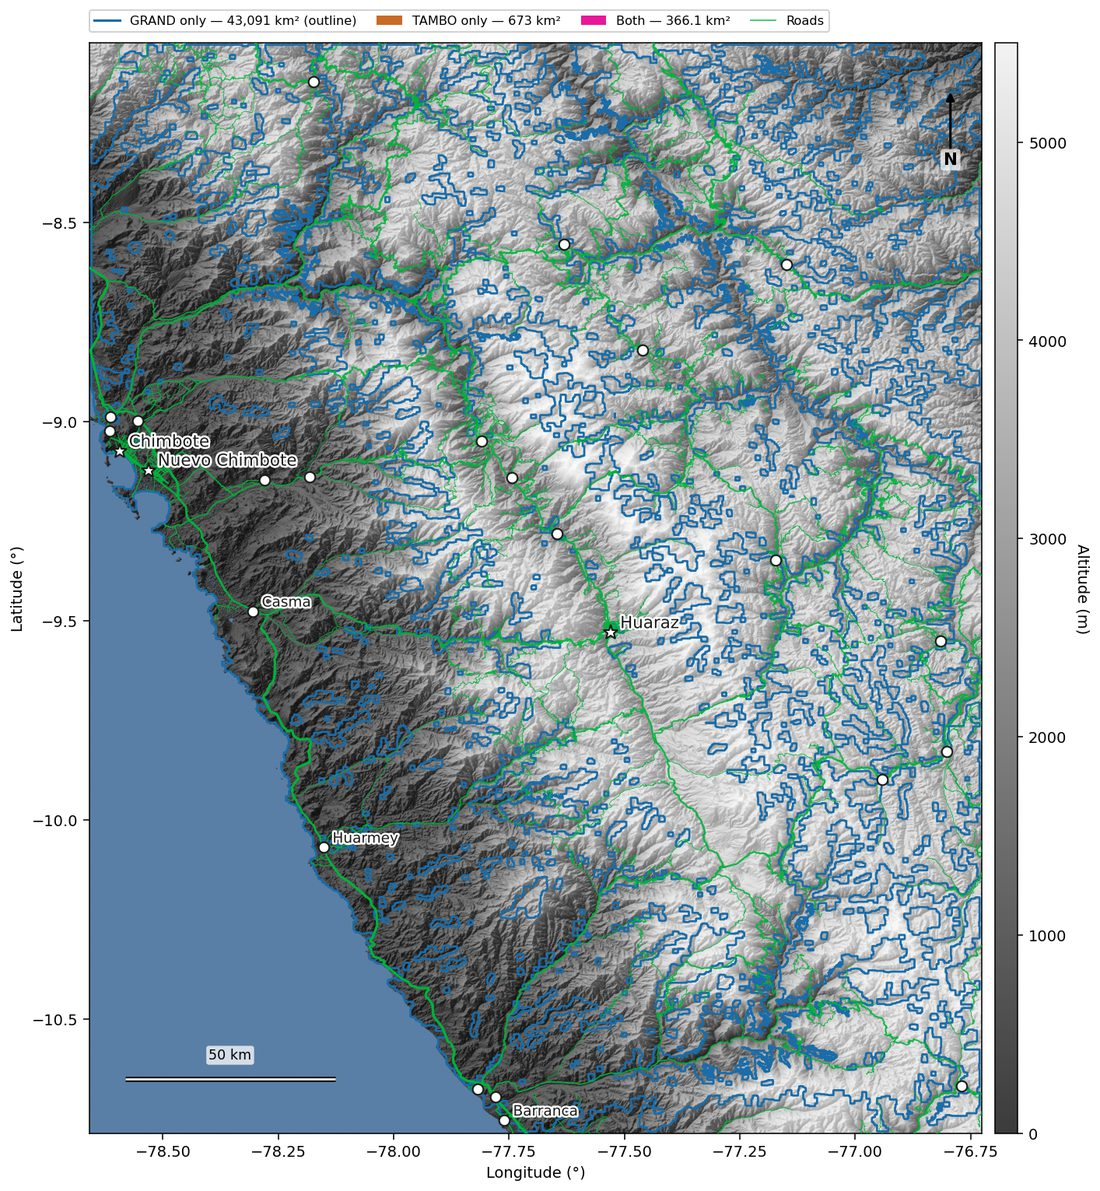

TAMBO alone


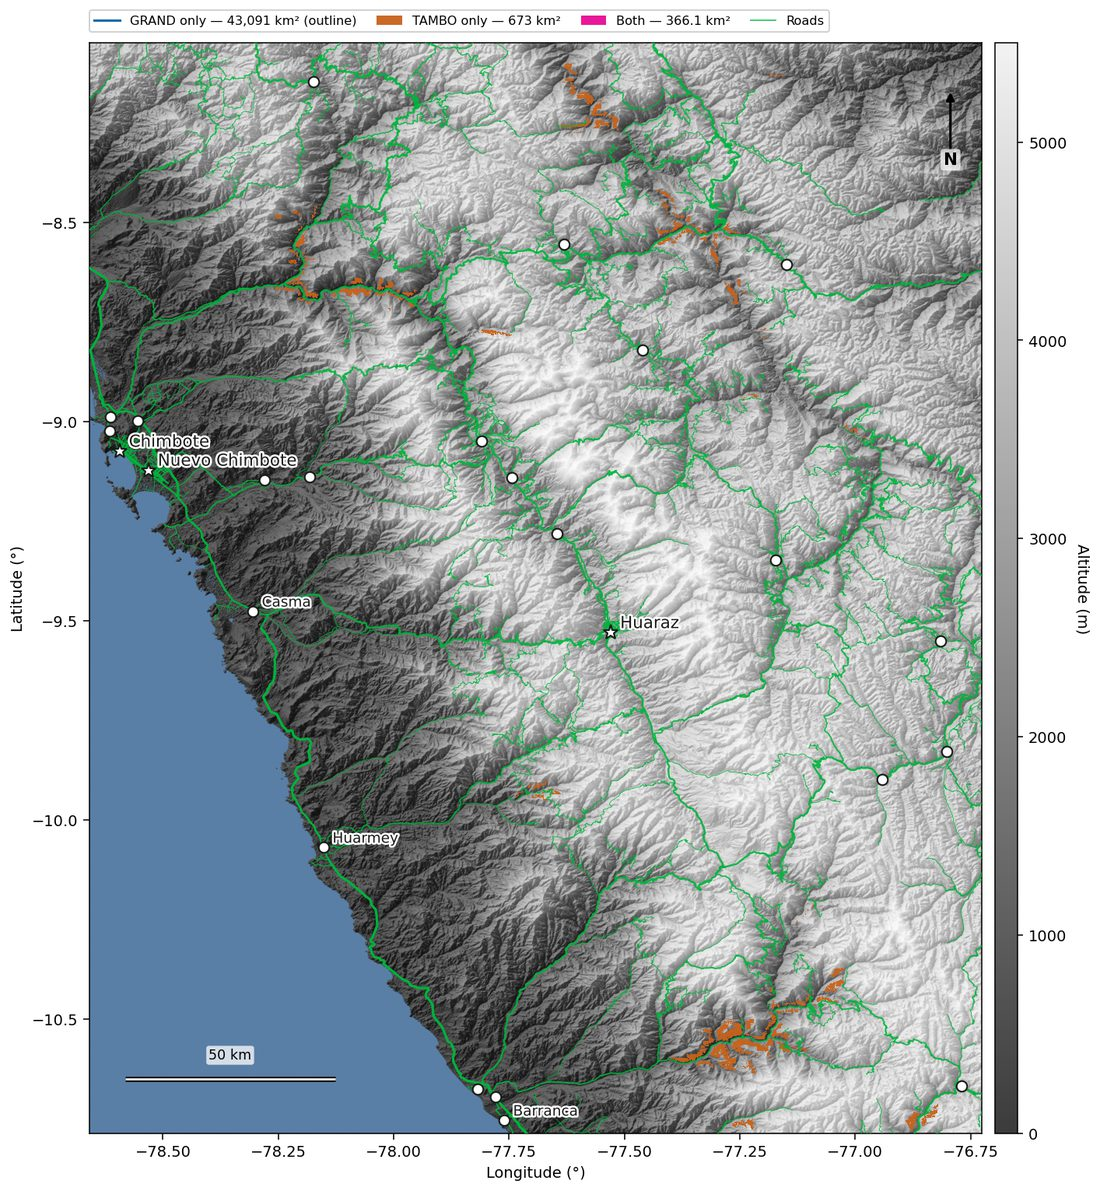

Both — the joint ground


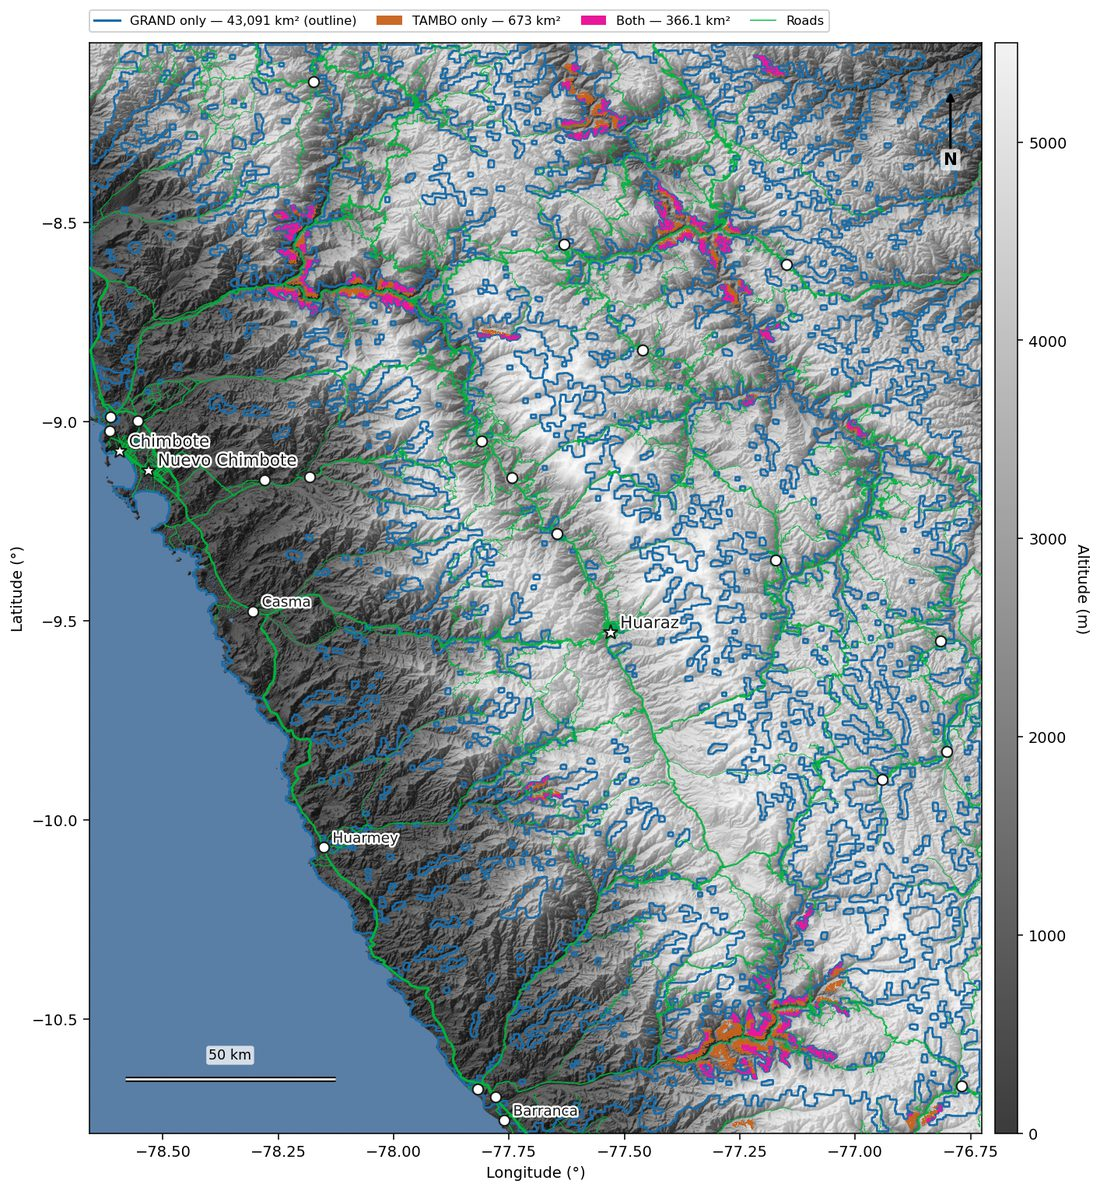

In [10]:
def show_stage(name, caption):
    show_figure(os.path.join(OUT, "ancash_full_combined", name), caption=caption)


for frame, caption in (("combined_overview_1_grand.png", "GRAND alone"),
                       ("combined_overview_2_tambo.png", "TAMBO alone"),
                       ("combined_overview_3_both.png", "Both — the joint ground")):
    show_stage(frame, caption)

In [11]:
def joint(store):
    path = os.path.join(store, "combined_report.json")
    if not os.path.exists(path):
        return None
    with open(path) as f:
        report = json.load(f)
    overlap = report["pairwise_overlap"]["GRAND & TAMBO"]
    return {"joint km2": report["joint"]["area_km2"],
            "jaccard": overlap["jaccard"],
            "share of TAMBO": 100.0 * overlap["fraction_of_TAMBO"]}


rows = {"Arequipa": joint(AREQUIPA_STORE), "Ancash": joint(STORE)}
rows = {k: v for k, v in rows.items() if v}
if rows:
    fmt = {"joint km2": "{:>18.1f}", "jaccard": "{:>18.5f}",
           "share of TAMBO": "{:>18.1f}"}
    cols = list(next(iter(rows.values())))
    print(f"{'':<10}" + "".join(f"{c:>18}" for c in cols))
    for name, row in rows.items():
        print(f"{name:<10}" + "".join(fmt[c].format(row[c]) for c in cols))

                   joint km2           jaccard    share of TAMBO
Arequipa               597.9           0.00672              60.3
Ancash                 366.1           0.00844              54.4


**The joint area nearly doubles**, and per pixel it is 2.81× — tracking TAMBO
rather than GRAND, which is what you would expect if the joint region is limited by the
scarcer of the two.

The last column is the one to keep. **The joint region is 44.9% of TAMBO's mask at
Arequipa and 43.0% at Ancash** — essentially unchanged across two regions whose terrain
could hardly be more different. Co-location costs GRAND almost nothing and consumes
roughly half of what TAMBO has, wherever you look. The Jaccard index tripling is not the
two experiments agreeing more; it is TAMBO's mask growing while GRAND's shrinks.

---

## Zooming in: the Callejón de Huaylas and the Cañón del Pato

The department run above uses `downsample_factor` 4 and `candidate_stride` 5, because
69 Mpx will not fit in a desktop otherwise. Both cost area. **A crop is small enough to
run without either**, so the Río Santa valley between the Cordillera Blanca and the
Cordillera Negra — 11.4 million pixels, `−8.80…−9.90` lat, `−78.00…−77.20` lon — was cut
out and searched at 1 and 1.

```bash
cd src && oroscope-crop ../input/dem/ancash_SRTMGL1.tif ../input/dem/huaylas.tif     --north -8.80 --south -9.90 --west -78.00 --east -77.20
python tools/run_full_dem.py --region huaylas
```

In [12]:
HUAYLAS = os.path.abspath(os.path.join("..", "results", "huaylas_full"))


def crop_summary(path):
    if not os.path.exists(path):
        return None
    with open(path) as f:
        d = json.load(f)
    r = d["results"]
    sites = r.get("sites") or []
    return {"sites": r["total_sites"],
            "area km2": sum(s.get("area_km2", 0.0) for s in sites),
            "capacity": r["total_capacity"]}


print(f"{'':<40}{'sites':>8}{'area km2':>12}{'capacity':>12}")
for label in ("grand", "tambo"):
    for tag, path in (
            ("unbiased, ds 1 / stride 1",
             os.path.join(HUAYLAS, f"{label}_results.json")),
            ("control, ds 4 / stride 5",
             os.path.join(HUAYLAS, f"{label}_control_ds4_stride5.json"))):
        s = crop_summary(path)
        if s:
            print(f"{label.upper() + ', ' + tag:<40}{s['sites']:>8,}"
                  f"{s['area km2']:>12,.1f}{s['capacity']:>12,}")

                                           sites    area km2    capacity
GRAND, unbiased, ds 1 / stride 1               1     8,294.9       9,609
GRAND, control, ds 4 / stride 5                1     7,537.9       8,658
TAMBO, unbiased, ds 1 / stride 1              23       218.8      11,280
TAMBO, control, ds 4 / stride 5                1         2.9         256


**The same ground, the same criteria, and only the sampling changed.** GRAND
moves by 1.1×. TAMBO moves by **291× in area and 386× in capacity**, and from 109 sites
to one.

That is not the 4.75× recorded in `docs/ROADMAP.md` §6.34. That figure was measured on
Colca varying the stride alone; here both levers move, on terrain whose accepted strips
are numerous and individually small.

The funnels say exactly where it goes, and it is not where you would guess.

In [13]:
def funnel_of(path):
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)["funnel"]


a = funnel_of(os.path.join(HUAYLAS, "tambo_results.json"))
b = funnel_of(os.path.join(HUAYLAS, "tambo_control_ds4_stride5.json"))
if a and b:
    print(f"{'stage':<34}{'ds 1 / stride 1':>18}{'ds 4 / stride 5':>18}")
    for k in a:
        if k in b:
            print(f"{k:<34}{a[k]:>18,}{b[k]:>18,}")
    acc_a = 100 * a["directions accepted"] / a["slope 20.0-60.0 deg"]
    strided_b = next(v for k, v in b.items() if k.startswith("kept by stride"))
    acc_b = 100 * b["directions accepted"] / strided_b
    print(f"\nacceptance: {acc_a:.1f}% at stride 1, {acc_b:.1f}% at stride 5")

stage                                ds 1 / stride 1   ds 4 / stride 5
DEM pixels                                11,411,641        11,411,641
finite elevation                          11,411,641        11,411,641
slope 20.0-60.0 deg                        7,081,749         7,081,749
directions accepted                        5,872,344           198,353
score >= 0.35                                438,138           198,353
after gap closing                            640,983           477,816
after pruning (< 0.0 km wide)                640,983           477,816
pixels in selected sites (est.)              233,471             3,136

acceptance: 82.9% at stride 1, 14.0% at stride 5


**Acceptance is identical — 14.0% either way.** Striding really is unbiased
there, exactly as §6.34 says. Closing differs by only 2.6×. *All* of the 291× happens
between closing and selection, in the region thresholds: at stride 5 the mask fragments
into 7,954 labelled regions, of which 5 clear the area threshold and **one** clears
`min_sub_array_size` of 250 detectors. At stride 1 the mask is contiguous and 109 regions
survive.

So the under-report is **fragmentation meeting a minimum-array-size cut**, not pixels
being miscounted. GRAND never suffers it because a 1 km closing element bridges a 154 m
stride gap without noticing.

**What to take from this.** Every TAMBO area and capacity in this project that came from
a strided, downsampled run is a lower bound by a factor that is terrain-dependent and, in
practice, unbounded — 4.75× at Colca, 291× here. Quote TAMBO numbers from unbiased runs,
or quote them as "at least". The Callejón de Huaylas was effectively invisible to the
department run: its TAMBO mask contributes **1.2 km² inside this crop window** against
the crop's own 855.1 km².

### The zoom-in, drawn

The crop's own maps. `--reveal` writes the combination one experiment at a time, so the
same frame can be read three ways: GRAND alone, TAMBO alone, and the ground that
satisfies both. Everything that is not a category — terrain, colour bar, roads, towns,
scale bar — is identical between them.

GRAND over the crop — one site, 8,295 km²


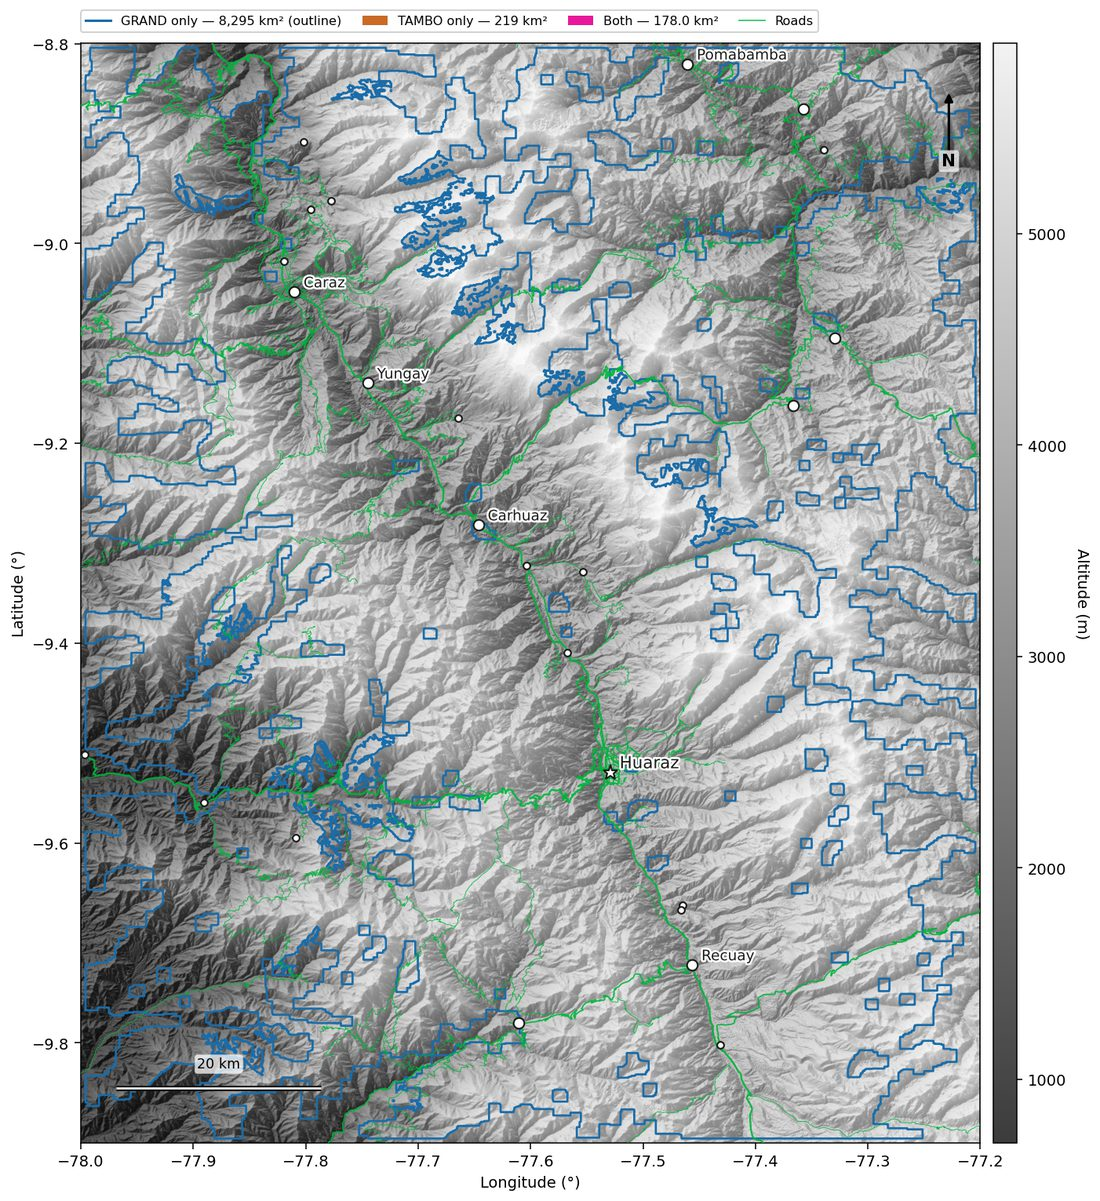

TAMBO over the crop at stride 1 — 109 sites along the Río Santa


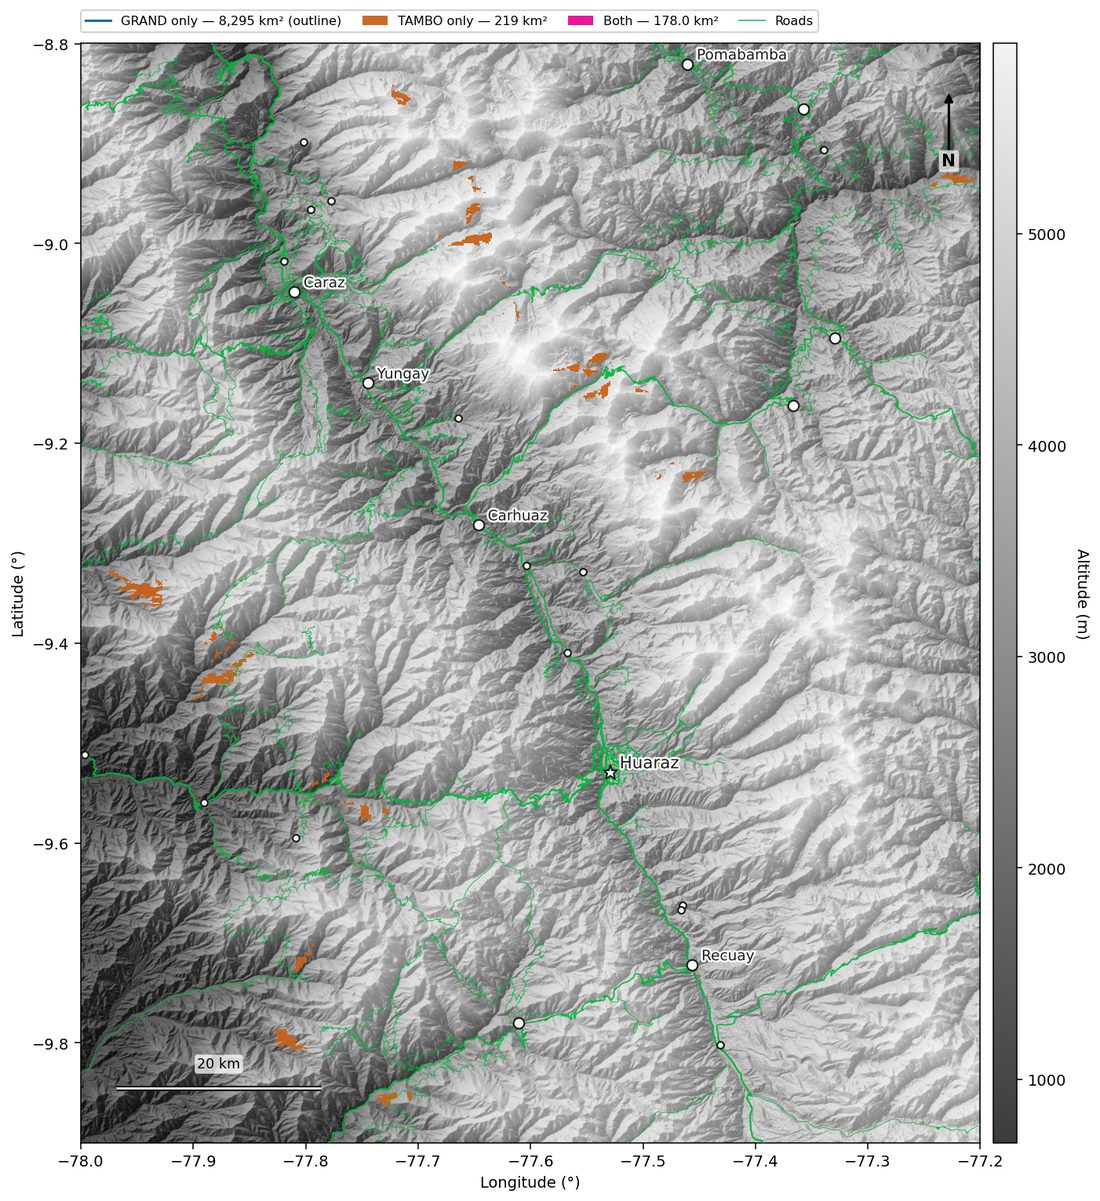

Both — 637 km² of joint ground, 74.5% of TAMBO's mask


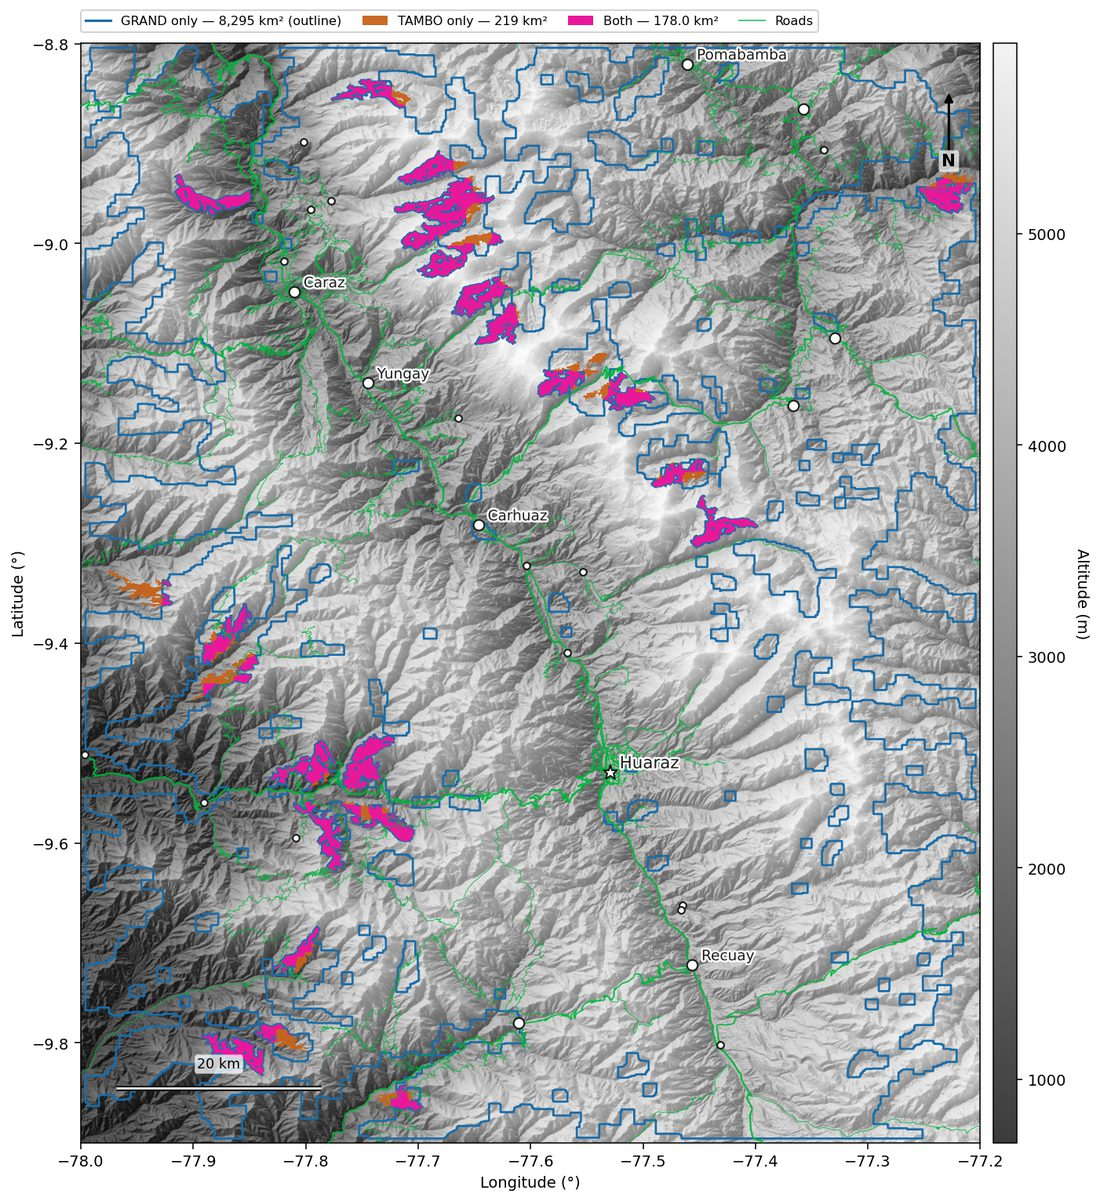

In [14]:
CROP_OUT = os.path.abspath(os.path.join("..", "output", "huaylas_full_combined"))
for frame, caption in (
        ("combined_overview_1_grand.png",
         "GRAND over the crop — one site, 8,295 km²"),
        ("combined_overview_2_tambo.png",
         "TAMBO over the crop at stride 1 — 109 sites along the Río Santa"),
        ("combined_overview_3_both.png",
         "Both — 637 km² of joint ground, 74.5% of TAMBO's mask")):
    show_figure(os.path.join(CROP_OUT, frame), caption=caption)

**And the same TAMBO search at the department run's sampling**, for the
comparison the numbers above make. One picture is 109 sites; the other is one.

TAMBO on the same crop at downsample 4 / stride 5 — the control


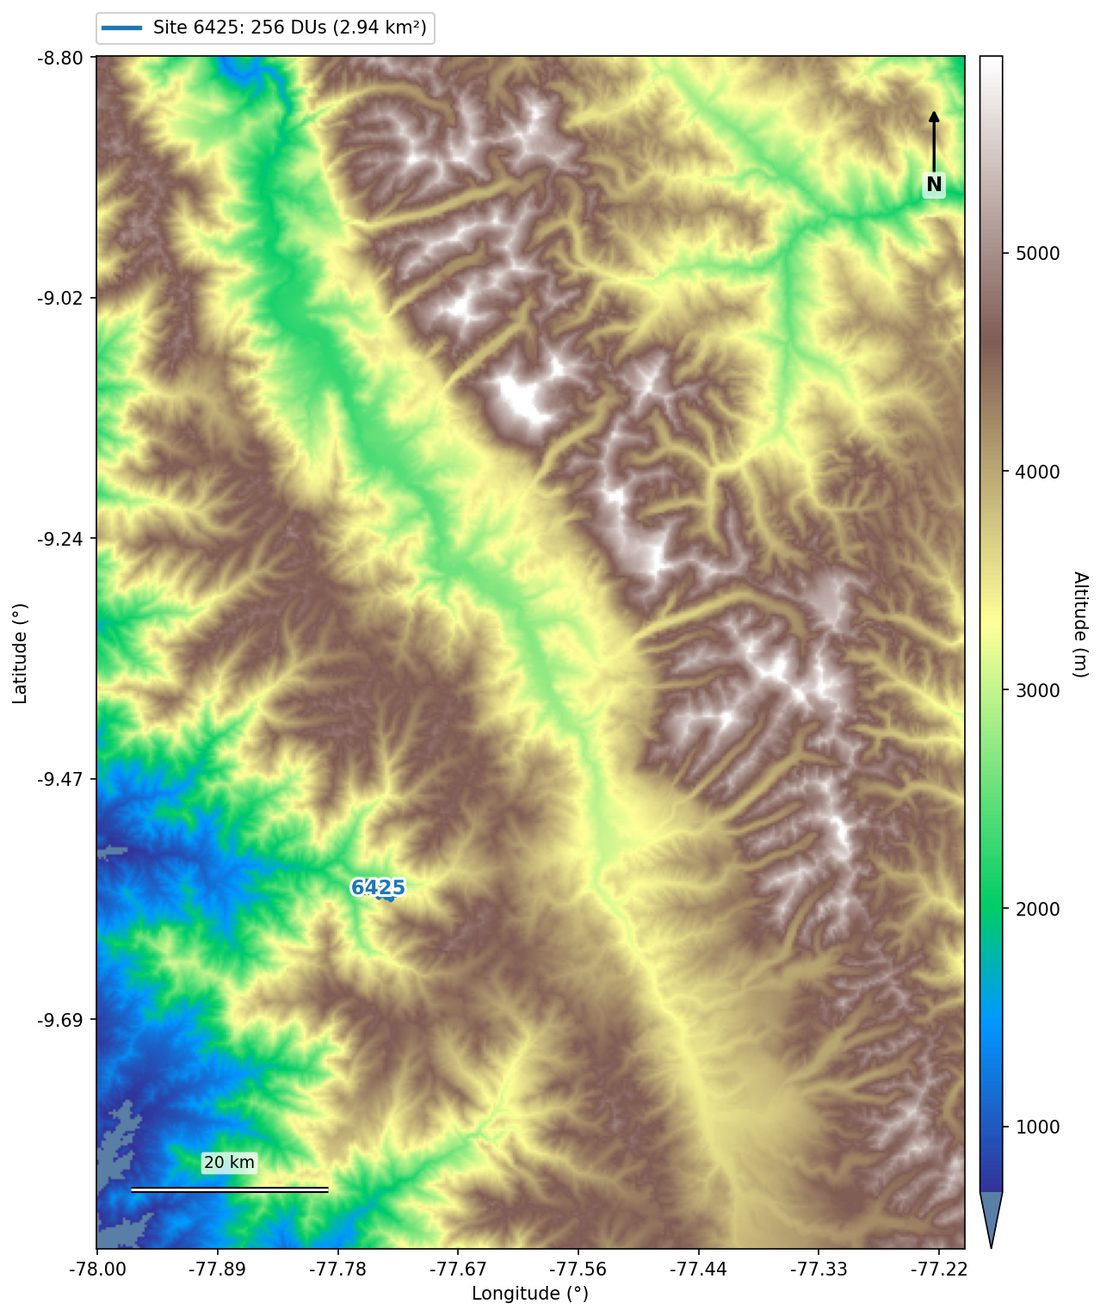

In [15]:
show_figure(os.path.abspath(os.path.join(
                "..", "output", "huaylas_ctl_tambo", "oroscope_results_huaylas.png")),
            caption="TAMBO on the same crop at downsample 4 / stride 5 — the control")

---

## The full explanation of each run

Every search writes a plain-language account of itself — what it found, where the
candidates went, why each site qualifies, which numbers are assumptions and how to read
them. Those are reproduced here in full rather than summarised, because the caveats
matter as much as the totals.

In [16]:
def explanation(store, name):
    path = os.path.join(store, name)
    if not os.path.exists(path):
        print(f"not in the store: {os.path.basename(path)}")
        return
    with open(path) as f:
        print(f.read())


explanation(STORE, "grand_explanation.txt")

 WHAT THIS SEARCH FOUND, AND WHY

THE RUN
-------
  DEM              /home/mbustamante/Research/GRAND/oroscope/input/dem/ancash_SRTMGL1.tif
  Origin           -8.049583, -78.658750  (auto-detected from the GeoTIFF tiepoint)
  Resolution       0.00027778°/px  =  30.7 m N-S x 30.5 m E-W
  Layout           distributed search, hex grid, 1.0 km spacing
  Finished         2026-08-16 16:42:37
  Code             commit 5346916 on dev (dirty tree)
  DEM checksum     sha256 182f1b4e41cfc381…
  Command          tools/run_full_dem.py --region ancash --max-memory-gb 5.0

THE HEADLINE
------------
  1 site covering 43,091.2 km², 49,447 detectors against a target of 10,000.

  Largest by capacity: site 2, 43,091.19 km², 49,447 detectors, facing S,
  centred -9.2862, -77.6182 — paste that into a map.

WHERE THE CANDIDATES WENT
-------------------------
  stage                           |         pixels |   of DEM |  of prev
  ----------------------------------------------------------------------
  DEM

In [17]:
explanation(STORE, "tambo_explanation.txt")

 WHAT THIS SEARCH FOUND, AND WHY

THE RUN
-------
  DEM              /home/mbustamante/Research/GRAND/oroscope/input/dem/ancash_SRTMGL1.tif
  Origin           -8.049583, -78.658750  (auto-detected from the GeoTIFF tiepoint)
  Resolution       0.00027778°/px  =  30.7 m N-S x 30.5 m E-W
  Layout           distributed search, hex grid, 0.15 km spacing
  Finished         2026-08-16 22:25:50
  Code             commit 84d4d3e on dev (dirty tree)
  DEM checksum     sha256 182f1b4e41cfc381…
  Command          tools/run_full_dem.py --region ancash --only tambo

THE HEADLINE
------------
  58 sites covering 673.1 km² between them, 31,249 detectors against a target
  of 5,000.

  Largest by capacity: site 13529, 29.69 km², 1,430 detectors, facing S,
  centred -10.5703, -77.2236 — paste that into a map.

WHERE THE CANDIDATES WENT
-------------------------
  stage                           |         pixels |   of DEM |  of prev
  ---------------------------------------------------------------------

In [18]:
explanation(STORE, "combination_explanation.txt")

 WHERE THESE EXPERIMENTS CAN SHARE GROUND, AND WHY

WHAT EACH BRINGS
----------------
  experiment |     area km² |   sites |  detectors |  in joint
  ----------------------------------------------------------
  GRAND      |     43,091.2 |       1 |     49,447 |      0.8%
  TAMBO      |        673.0 |      58 |     31,249 |     54.4%

  Ground satisfying GRAND and TAMBO at once: 366.1 km². Ground useful to any
  of them: 43,398.1 km². The first is the number that matters for one site,
  one road and one power feed serving two experiments; the second is what the
  programme as a whole could use.

WHAT DECIDES IT
---------------
  A pixel has one slope, one altitude and one aspect, and both experiments
  must accept those same values to stand on it. So co-location is settled by
  whichever of those bands they share least of — before any arrival geometry
  is considered.

  band               |            GRAND |            TAMBO | shared
  ------------------------------------------------

In [19]:
explanation(HUAYLAS, "tambo_explanation.txt")

 WHAT THIS SEARCH FOUND, AND WHY

THE RUN
-------
  DEM              /home/mbustamante/Research/GRAND/oroscope/input/dem/huaylas.tif
  Origin           -8.799861, -78.000139  (auto-detected from the GeoTIFF tiepoint)
  Resolution       0.00027778°/px  =  30.7 m N-S x 30.5 m E-W
  Layout           distributed search, hex grid, 0.15 km spacing
  Finished         2026-08-16 22:24:20
  Code             commit 84d4d3e on dev (dirty tree)
  DEM checksum     sha256 32be99fb9353584e…
  Command          tools/run_full_dem.py --region huaylas --only tambo

THE HEADLINE
------------
  23 sites covering 218.8 km² between them, 11,280 detectors against a target
  of 5,000.

  Largest by capacity: site 1006, 24.82 km², 1,283 detectors, facing S,
  centred -8.9685, -77.6753 — paste that into a map.

WHERE THE CANDIDATES WENT
-------------------------
  stage                           |         pixels |   of DEM |  of prev
  ----------------------------------------------------------------------
  DEM 

## Where to go next

- **[9. Arequipa, the full DEM](09_arequipa_dem.ipynb)** — the run this one is held
  against, and the place to read the caveats that apply to both.
- **[12. Peru, all of it](12_peru_dem.ipynb)** — the whole country at a third of the
  resolution, and what that costs.
- **[6. Combining and sensitivity](06_combining_and_sensitivity.ipynb)** — how much of
  any of this survives a change of assumption.

---

*Part of the [Oroscope](https://github.com/mbustama/oroscope) tutorials. Previous: [Arequipa, the full DEM](09_arequipa_dem.ipynb). Next: [Lima](11_lima_dem.ipynb). Full API reference: [oroscope docs](https://mbustama.github.io/oroscope/functions.html).*